# Creating a playing cards dataset
This notebook is a guide through the creation of a dataset of playing cards. The cards are labeled with their name (ex: "2c" for "2 of spades", "Kh" for King for hearts) and with the bounding boxes delimiting their printed corners.
> _Why bounding boxes around the corners, and not around the whole card ?_<br>Because in real conditions, more often than not, cards are partially covered. And the corner of a card is the minimum information you need to identify it.

This dataset can be used for the training of a neural net intended to detect/localize playing cards. It was used on the project __[Playing card detection with YOLO v3](https://youtu.be/pnntrewH0xg)__

<img src="img/ex_generated_image.png" alt="Example of generated image "  title="Example of generated image " />


# Prerequisites 

### A. In addition to opencv and numpy, you need the following python packages :
1. **imgaug** : https://github.com/aleju/imgaug 
> Helps with image augmentation
2. **shapely** : https://github.com/Toblerity/Shapely
> For the manipulation and analysis of geometric objects in the Cartesian plane. It is useful here when we want to check if the bounding box of a card corner is covered by another card
3. **tqdm** : https://github.com/tqdm/tqdm
> A progress bar tool. Not mandatory but convenient when you generate thousands of images

### B. Get the Describable Textures Dataset (DTD)
> A collection of textural images in the wild (https://www.robots.ox.ac.uk/~vgg/data/dtd/). It is probably not its original goal, but it is used here as an easy way to generate various backgrounds for our images.

### C. A real deck of cards
> This the only physical "data" you need. You have to make some measurements on the cards, and to take a picture/shoot a movie of each of the 52 cards of the deck. Everything else will be generated by scripts.


#### C.1 Measurements on the cards
Use a ruler to measure the dimensions as indicated in the image below. 
For the corner* measures, the idea is to delimit one rectangular zone that can hold every value+suit. The size of the marks may vary with the value or the suit, so take the measures on the cards with the widest, the tallest symbols, and add one or two millimeters. 
<img src="img/measures.png" alt="Measures" title="" />
Report the measures in mm in the cell below (and don't forget to run the cell).

In [1]:
cardW=63
cardH=88
cornerXmin=2.0
cornerXmax=13
cornerYmin=1.5
cornerYmax=20

# We convert the measures from mm to pixels: multiply by an arbitrary factor 'zoom'
# You shouldn't need to change this
zoom=4
cardW*=zoom
cardH*=zoom
cornerXmin=int(cornerXmin*zoom)
cornerXmax=int(cornerXmax*zoom)
cornerYmin=int(cornerYmin*zoom)
cornerYmax=int(cornerYmax*zoom)

#### C.2 Shoot one video per card
That's what I did in the project "Playing card detection with YOLO v3", and the scripts in this notebook were written to deal with videos. A video is interesting only if you can vary the brightness and color temperature of the light during the shot. Watch [Playing card detection with YOLO v3](https://www.youtube.com/watch?v=pnntrewH0xg&t=4m10s) to have an idea. 
With hindsight, I am confident that you could use one picture per card instead of a video without affecting the efficiency of the neural net. The scripts could be easily adapted to deal with pictures.
Whether you use videos or pictures, the scene must be simple, with a uniform background behind the card, like below. This way, the extraction of the card from the scene will be easy.
<img src="test/scene.png" alt="Scene" title="Scene" />

## Imports

In [2]:
import numpy as np
import cv2
import os
from tqdm import tqdm
import random
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import pickle
from glob import glob 
import imgaug as ia
from imgaug import augmenters as iaa
from shapely.geometry import Polygon


## Some convenient functions used in this notebook

In [3]:

def display_img(img,polygons=[],channels="bgr",size=9):
    """
        Function to display an inline image, and draw optional polygons (bounding boxes, convex hulls) on it.
        Use the param 'channels' to specify the order of the channels ("bgr" for an image coming from OpenCV world)
    """
    if not isinstance(polygons,list):
        polygons=[polygons]    
    if channels=="bgr": # bgr (cv2 image)
        nb_channels=img.shape[2]
        if nb_channels==4:
            img=cv2.cvtColor(img,cv2.COLOR_BGRA2RGBA)
        else:
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)    
    fig,ax=plt.subplots(figsize=(size,size))
    ax.set_facecolor((0,0,0))
    ax.imshow(img)
    for polygon in polygons:
        # An polygon has either shape (n,2), 
        # either (n,1,2) if it is a cv2 contour (like convex hull).
        # In the latter case, reshape in (n,2)
        if len(polygon.shape)==3:
            polygon=polygon.reshape(-1,2)
        patch=patches.Polygon(polygon,linewidth=1,edgecolor='g',facecolor='none')
        ax.add_patch(patch)

def give_me_filename(dirname, suffixes, prefix=""):
    """
        Function that returns a filename or a list of filenames in directory 'dirname'
        that does not exist yet. If 'suffixes' is a list, one filename per suffix in 'suffixes':
        filename = dirname + "/" + prefix + random number + "." + suffix
        Same random number for all the file name
        Ex: 
        > give_me_filename("dir","jpg", prefix="prefix")
        'dir/prefix408290659.jpg'
        > give_me_filename("dir",["jpg","xml"])
        ['dir/877739594.jpg', 'dir/877739594.xml']        
    """
    if not isinstance(suffixes, list):
        suffixes=[suffixes]
    
    suffixes=[p if p[0]=='.' else '.'+p for p in suffixes]
          
    while True:
        bname="%09d"%random.randint(0,999999999)
        fnames=[]
        for suffix in suffixes:
            fname=os.path.join(dirname,prefix+bname+suffix)
            if not os.path.isfile(fname):
                fnames.append(fname)
                
        if len(fnames) == len(suffixes): break
    
    if len(fnames)==1:
        return fnames[0]
    else:
        return fnames
    

def ensure_dir(path):
    if not os.path.isdir(path):
        os.makedirs(path)

# Define global variables

In [4]:
data_dir="data" # Directory that will contain all kinds of data (the data we download and the data we generate)

if not os.path.isdir(data_dir):
    os.makedirs(data_dir)

# Pickle file containing the background images from the DTD
backgrounds_pck_fn=data_dir+"/backgrounds.pck"

# Pickle file containing the card images
cards_pck_fn=data_dir+"/cards.pck"


# imgW,imgH: dimensions of the generated dataset images 
imgW=720
imgH=720


refCard=np.array([[0,0],[cardW,0],[cardW,cardH],[0,cardH]],dtype=np.float32)
refCardRot=np.array([[cardW,0],[cardW,cardH],[0,cardH],[0,0]],dtype=np.float32)

refCornerHL = np.array([
    [cornerXmin, cornerYmin],
    [cornerXmax, cornerYmin],
    [cornerXmax, cornerYmax],
    [cornerXmin, cornerYmax]
], dtype=np.float32)

refCornerHR = np.array([
    [cardW - cornerXmax, cornerYmin],
    [cardW - cornerXmin, cornerYmin],
    [cardW - cornerXmin, cornerYmax],
    [cardW - cornerXmax, cornerYmax]
], dtype=np.float32)

refCornerLR = np.array([
    [cardW - cornerXmax, cardH - cornerYmax],
    [cardW - cornerXmin, cardH - cornerYmax],
    [cardW - cornerXmin, cardH - cornerYmin],
    [cardW - cornerXmax, cardH - cornerYmin]
], dtype=np.float32)

refCornerLL = np.array([
    [cornerXmin, cardH - cornerYmax],
    [cornerXmax, cardH - cornerYmax],
    [cornerXmax, cardH - cornerYmin],
    [cornerXmin, cardH - cornerYmin]
], dtype=np.float32)

refCorners = np.array([refCornerHL, refCornerHR, refCornerLR, refCornerLL], dtype=np.float32)

### Get Card Names and Generate Card Name File

In [5]:
card_media_dir = "data/card_scans/seperated"
card_names = [os.path.splitext(f.name)[0] for f in os.scandir(card_media_dir) if f.is_file()]

print(f"names: [{", ".join(f"'{name}'" for name in card_names)}]")

with open("data/cards.names", "w") as file:
    for name in card_names:
        file.write(name + "\n")

names: ['black10', 'black2', 'black3', 'black4', 'black5', 'black6', 'black7', 'black8', 'black9', 'blacka', 'blackj', 'blackk', 'blackq', 'blue10', 'blue2', 'blue3', 'blue4', 'blue5', 'blue6', 'blue7', 'blue8', 'blue9', 'bluea', 'bluej', 'bluek', 'blueq', 'dog', 'dragon', 'green10', 'green2', 'green3', 'green4', 'green5', 'green6', 'green7', 'green8', 'green9', 'greena', 'greenj', 'greenk', 'greenq', 'mahjong', 'phoenix', 'red10', 'red2', 'red3', 'red4', 'red5', 'red6', 'red7', 'red8', 'red9', 'reda', 'redj', 'redk', 'redq']


# Get Describable Textures Dataset (DTD)
A convenient way to generate backgrounds for the images of the cards dataset

### Download DTD (1x)

In [ ]:
#!wget https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz

### Extract the DTD (1x)

In [ ]:
#!tar xf dtd-r1.0.1.tar.gz

### Load all *jpg from dtd subdirectories and save them in a pickle file (1x)

The next times, we will directly load the pickle file 

In [ ]:
dtd_dir="dtd/images/"
bg_images=[]
for subdir in glob(dtd_dir+"/*"):
    for f in glob(subdir+"/*.jpg"):
        bg_images.append(mpimg.imread(f))
print("Nb of images loaded :",len(bg_images))
print("Saved in :",backgrounds_pck_fn)
pickle.dump(bg_images,open(backgrounds_pck_fn,'wb'))

In [ ]:
# Clean-up
#!rm -r dtd
#!rm dtd-r1.0.1.tar.gz

### Load the backgounds pickle file in 'backgrounds'
'backgrounds' is an instance of the class Backgrounds
To get a random background image, call the method : backgrounds.get_random

In [6]:
class Backgrounds():
    def __init__(self,backgrounds_pck_fn=backgrounds_pck_fn):
        self._images=pickle.load(open(backgrounds_pck_fn,'rb'))
        self._nb_images=len(self._images)
        print("Nb of images loaded :", self._nb_images)
    def get_random(self, display=False):
        bg=self._images[random.randint(0,self._nb_images-1)]
        if display: plt.imshow(bg)
        return bg
    
backgrounds = Backgrounds()


Nb of images loaded : 5640


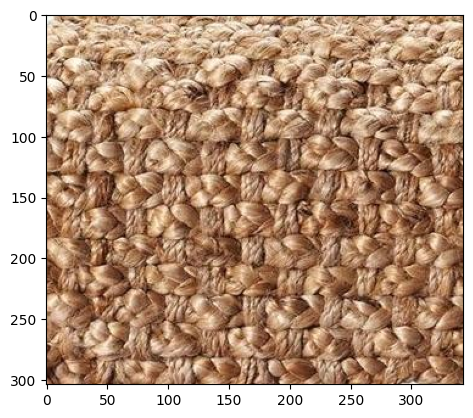

In [7]:
# Test: display a random background
_=backgrounds.get_random(display=True)

# Extraction of the cards from pictures or video 

### Define the alphamask
The alphamask has 2 purposes:
- clean the border of the detected cards,
- make that border transparent. Cards are not perfect rectangles because corners are rounded. We need to make transparent the zone between the real card and its bounding rectangle, otherwise this zone will be visible in the final generated images of the dataset


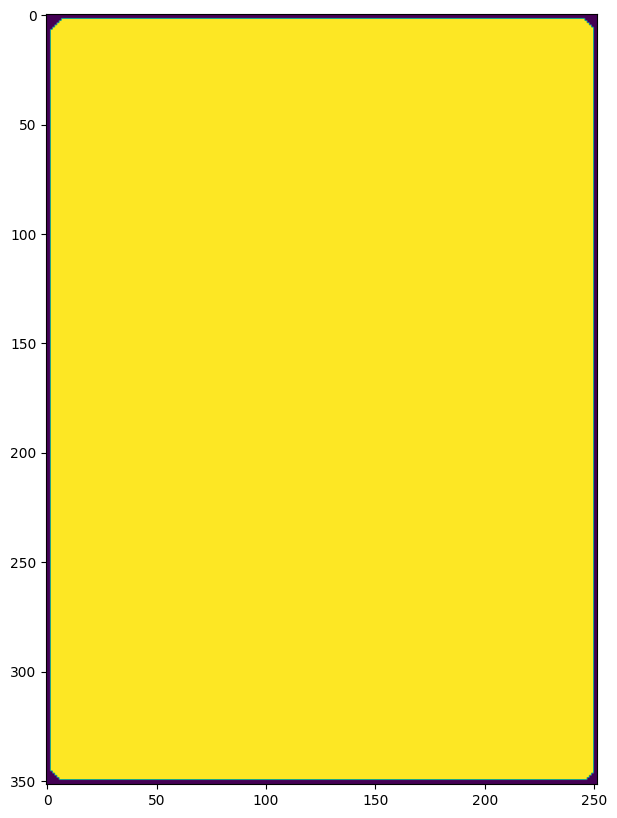

In [8]:
bord_size=2 # bord_size alpha=0
alphamask=np.ones((cardH,cardW),dtype=np.uint8)*255
cv2.rectangle(alphamask,(0,0),(cardW-1,cardH-1),0,bord_size)
cv2.line(alphamask,(bord_size*3,0),(0,bord_size*3),0,bord_size)
cv2.line(alphamask,(cardW-bord_size*3,0),(cardW,bord_size*3),0,bord_size)
cv2.line(alphamask,(0,cardH-bord_size*3),(bord_size*3,cardH),0,bord_size)
cv2.line(alphamask,(cardW-bord_size*3,cardH),(cardW,cardH-bord_size*3),0,bord_size)
plt.figure(figsize=(10,10))
plt.imshow(alphamask)

## Function extract_card 
Extract from scene image (cv2/bgr) the part corresponding to the card and transforms it 
to fit into the reference card shape.
We suppose here that the user facilitates as much as he can the extraction task by
making the scene image simple (one card on uniform backgroung, not too blurry, correct lighting,...)

In [9]:
def varianceOfLaplacian(img):
    """
    Compute the Laplacian of the image and then return the focus
    measure, which is simply the variance of the Laplacian
    Source: A.Rosebrock, https://www.pyimagesearch.com/2015/09/07/blur-detection-with-opencv/
    """
    return cv2.Laplacian(img, cv2.CV_64F).var()

def extract_card(img, output_fn=None, min_focus=120, debug=False):
    """
    """
    
    imgwarp=None
    
    # Check the image is not too blurry
    focus=varianceOfLaplacian(img)
    if focus < min_focus: 
        if debug: print("Focus too low :", focus)
        return False,None
    
    # Convert in gray color
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    
    # Noise-reducing and edge-preserving filter
    gray=cv2.bilateralFilter(gray,11,17,17)
    
    # Edge extraction
    edge=cv2.Canny(gray,30,200)
    
    # Find the contours in the edged image
    cnts, _ = cv2.findContours(edge.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # We suppose that the contour with largest area corresponds to the contour delimiting the card
    cnt = sorted(cnts, key = cv2.contourArea, reverse = True)[0]
    
    # We want to check that 'cnt' is the contour of a rectangular shape
    # First, determine 'box', the minimum area bounding rectangle of 'cnt'
    # Then compare area of 'cnt' and area of 'box'
    # Both areas sould be very close
    rect=cv2.minAreaRect(cnt)
    box=cv2.boxPoints(rect)
    box=box.astype(np.int32)                                #np.int0(box)
    areaCnt=cv2.contourArea(cnt)
    areaBox=cv2.contourArea(box)
    valid=areaCnt/areaBox>0.7
    
    if valid:
        # We want transform the zone inside the contour into the reference rectangle of dimensions (cardW,cardH)
        ((xr,yr),(wr,hr),thetar)=rect
        # Determine 'Mp' the transformation that transforms 'box' into the reference rectangle
        if wr>hr:
            Mp=cv2.getPerspectiveTransform(np.float32(box),refCard)
        else:
            Mp=cv2.getPerspectiveTransform(np.float32(box),refCardRot)
        # Determine the warped image by applying the transformation to the image
        imgwarp=cv2.warpPerspective(img,Mp,(cardW,cardH))
        # Add alpha layer
        imgwarp=cv2.cvtColor(imgwarp,cv2.COLOR_BGR2BGRA)
        
        # Shape of 'cnt' is (n,1,2), type=int with n = number of points
        # We reshape into (1,n,2), type=float32, before feeding to perspectiveTransform
        cnta=cnt.reshape(1,-1,2).astype(np.float32)
        # Apply the transformation 'Mp' to the contour
        cntwarp=cv2.perspectiveTransform(cnta,Mp)
        cntwarp=cntwarp.astype(np.int32)
        
        # We build the alpha channel so that we have transparency on the
        # external border of the card
        # First, initialize alpha channel fully transparent
        alphachannel=np.zeros(imgwarp.shape[:2],dtype=np.uint8)
        # Then fill in the contour to make opaque this zone of the card 
        cv2.drawContours(alphachannel,cntwarp,0,255,-1)
        
        # Apply the alphamask onto the alpha channel to clean it
        alphachannel=cv2.bitwise_and(alphachannel,alphamask)
        
        # Add the alphachannel to the warped image
        imgwarp[:,:,3]=alphachannel
        
        # Save the image to file
        if output_fn is not None:
            cv2.imwrite(output_fn,imgwarp)
        
    if debug:
        cv2.imshow("Gray",gray)
        cv2.imshow("Canny",edge)
        edge_bgr=cv2.cvtColor(edge,cv2.COLOR_GRAY2BGR)
        cv2.drawContours(edge_bgr,[box],0,(0,0,255),3)
        cv2.drawContours(edge_bgr,[cnt],0,(0,255,0),-1)
        cv2.imshow("Contour with biggest area",edge_bgr)
        if valid:
            cv2.imshow("Alphachannel",alphachannel)
            cv2.imshow("Extracted card",imgwarp)

    return valid,imgwarp

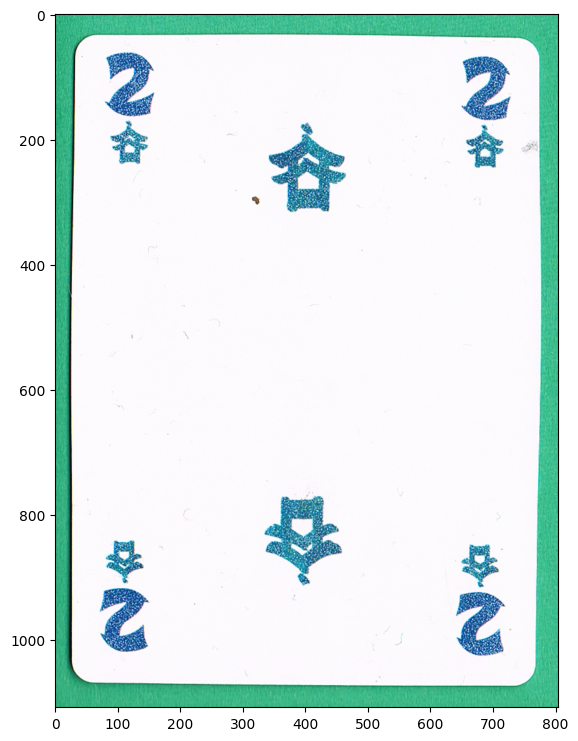

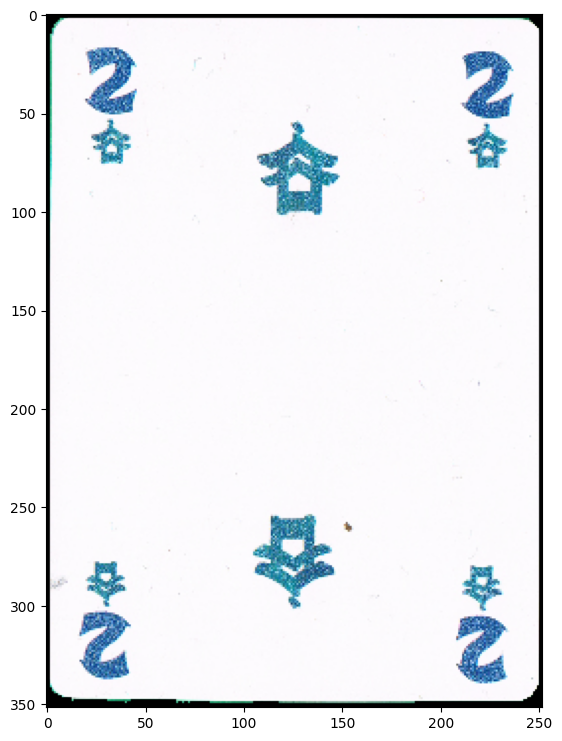

In [10]:
# Test on one image
debug=True
img=cv2.imread(f"{card_media_dir}/blue2.png")
display_img(img)
valid, card=extract_card(img,"test/extracted_card_tichu.png", min_focus=60, debug=False)
if valid:
    display_img(card)
if debug:
    cv2.waitKey(0)
    cv2.destroyAllWindows()

## Function extract_cards_from_media

In [11]:
import os
import cv2

def extract_cards_from_media(input_fn, output_dir=None, keep_ratio=5, min_focus=120, debug=False):
    """
    Extract cards from either:
      - a video file
      - a single image file (png/jpg/jpeg/...)

    If output_dir is specified, extracted cards are saved there.

    For videos:
      - only one frame every `keep_ratio` frames is processed

    For images:
      - the image is processed once

    Returns:
      list of extracted card images
    """
    if not os.path.isfile(input_fn):
        print(f"Input file {input_fn} does not exist !!!")
        return []

    if output_dir is not None and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
    video_exts = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".wmv"}

    ext = os.path.splitext(input_fn)[1].lower()
    imgs_list = []

    def process_image(img):
        if img is None:
            return

        output_fn = give_me_filename(output_dir, "png") if output_dir is not None else None
        valid, card_img = extract_card(img, output_fn, min_focus=min_focus, debug=debug)

        if debug:
            k = cv2.waitKey(0)
            if k == 27:
                return "stop"

        if valid:
            imgs_list.append(card_img)

    if ext in image_exts:
        img = cv2.imread(input_fn)
        result = process_image(img)
        if result == "stop":
            if debug:
                cv2.destroyAllWindows()
            return imgs_list

    elif ext in video_exts:
        cap = cv2.VideoCapture(input_fn)
        frame_nb = 0

        while True:
            ret, img = cap.read()
            if not ret:
                break

            if frame_nb % keep_ratio == 0:
                result = process_image(img)
                if result == "stop":
                    break

            frame_nb += 1

        cap.release()

    else:
        print(f"Unsupported file type: {ext}")
        return []

    if debug:
        cv2.destroyAllWindows()

    return imgs_list

In [12]:
imgs=extract_cards_from_media(f"{card_media_dir}/blue2.png", output_dir="test/2c", keep_ratio=5, min_focus=10, debug=True)
print("Nb images extracted:",len(imgs))

Nb images extracted: 1


# Card extraction from all the Media
We assume that for each card_name (e.g. 2d, Kc, Ah), there is exactly one corresponding file named:


`<card_name>.<extension>`

These files are stored in a common directory (e.g. data/video).

Examples:

2d.mp4, Kc.mp4, Ah.mp4 (for videos)
or 2d.png, Kc.png, Ah.png (for images)

If you want to use images instead of videos, simply set the variable extension to "jpg" or "png" in the script below.


In [13]:
extension = "png"
imgs_dir = "data/cards"

for card_name in card_names:
    fn = os.path.join(card_media_dir, card_name + "." + extension)
    output_dir = os.path.join(imgs_dir, card_name)

    if not os.path.isdir(output_dir):
        os.makedirs(output_dir)

    imgs = extract_cards_from_media(
        fn,
        output_dir,
        keep_ratio=1,
        min_focus=10,
        debug=False
    )

    print("Extracted images for %s : %d" % (card_name, len(imgs)))

Extracted images for black10 : 1
Extracted images for black2 : 1
Extracted images for black3 : 1
Extracted images for black4 : 1
Extracted images for black5 : 1
Extracted images for black6 : 1
Extracted images for black7 : 1
Extracted images for black8 : 1
Extracted images for black9 : 1
Extracted images for blacka : 1
Extracted images for blackj : 1
Extracted images for blackk : 1
Extracted images for blackq : 1
Extracted images for blue10 : 1
Extracted images for blue2 : 1
Extracted images for blue3 : 1
Extracted images for blue4 : 1
Extracted images for blue5 : 1
Extracted images for blue6 : 1
Extracted images for blue7 : 1
Extracted images for blue8 : 1
Extracted images for blue9 : 1
Extracted images for bluea : 1
Extracted images for bluej : 1
Extracted images for bluek : 1
Extracted images for blueq : 1
Extracted images for dog : 1
Extracted images for dragon : 1
Extracted images for green10 : 1
Extracted images for green2 : 1
Extracted images for green3 : 1
Extracted images for 

### Before going on, check that everything looks good
We randomly choose and display one of the extracted card. We also draw on the card the 2 polygons defined by refCornerHL and refCornerLR. Check that the value and suit symbols are well inside the polygons. If not, check the hand-made measures : cardW, cardH, cornerXmin, cornerXmax, cornerYmin and cornerYmax


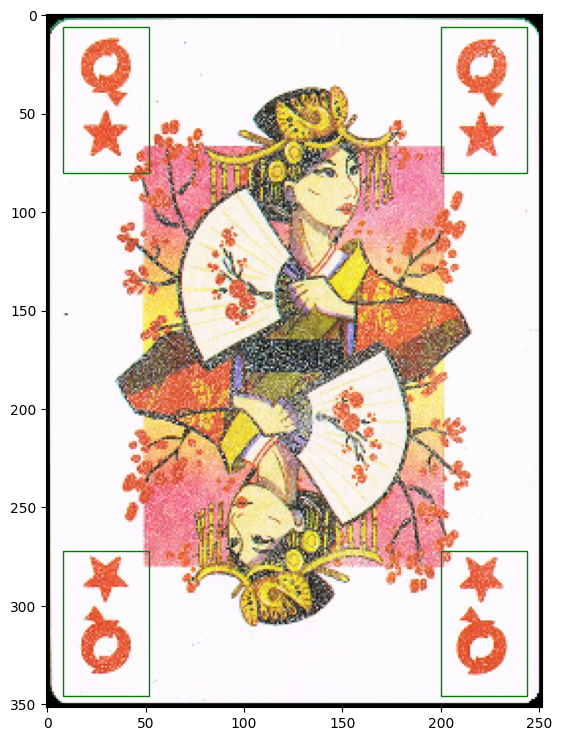

In [14]:
# Run a few times...
imgs_dir="data/cards"
imgs_fns=glob(imgs_dir+"/*/*.png")
img_fn=random.choice(imgs_fns)
display_img(cv2.imread(img_fn,cv2.IMREAD_UNCHANGED),polygons=[refCornerHL, refCornerHR, refCornerLL, refCornerLR])

# Finding the convex hulls
<img src="img/convex_hull.jpg" alt="Convex hull" title="Convex hull" />
This function 'find_hull' finds the convex hull in one of the corner of a card image.
The convex hull is the minimal convex polygon that contains both the value and the suit symbols. 

When I wrote this function it needed a lot of tweaking to make it work. It works well with my deck of cards, but I can't guarantee it is adapted to other decks. Search for the keyword TWEAK in the comments to find the variable and values that may need some tweak. Some of them depend on the value of global variable 'zoom'.
It may happen that the function can't find a valid convex hull for a card. It is not a problem, it only means that this card won't be used to generate the dataset.

In [15]:
def findHull(img, corner=refCornerHL, debug="no"):
    """
        Find in the zone 'corner' of image 'img' and return, the convex hull delimiting
        the value and suit symbols
        'corner' (shape (4,2)) is an array of 4 points delimiting a rectangular zone, 
        takes one of the 2 possible values : refCornerHL or refCornerLR
        debug=
    """
    
    kernel = np.ones((3,3),np.uint8)
    corner=corner.astype(np.int32)

    # We will focus on the zone of 'img' delimited by 'corner'
    x1=int(corner[0][0])
    y1=int(corner[0][1])
    x2=int(corner[2][0])
    y2=int(corner[2][1])
    w=x2-x1
    h=y2-y1
    zone=img[y1:y2,x1:x2].copy()

    strange_cnt=np.zeros_like(zone)
    gray=cv2.cvtColor(zone,cv2.COLOR_BGR2GRAY)
    thld=cv2.Canny(gray,30,200)
    thld = cv2.dilate(thld,kernel,iterations=1)
    if debug!="no": cv2.imshow("thld",thld)
    
    # Find the contours
    contours,_=cv2.findContours(thld.copy(),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    min_area=10 # We will reject contours with small area. TWEAK, 'zoom' dependant
    min_solidity=0.1 # Reject contours with a low solidity. TWEAK
    
    concat_contour=None # We will aggregate in 'concat_contour' the contours that we want to keep
    
    ok=True
    for c in contours:
        area=cv2.contourArea(c)

        hull = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull)
        solidity = float(area)/hull_area
        # Determine the center of gravity (cx,cy) of the contour
        M=cv2.moments(c)
        cx=int(M['m10']/M['m00'])
        cy=int(M['m01']/M['m00'])
        #  abs(w/2-cx)<w*0.3 and abs(h/2-cy)<h*0.4 : TWEAK, the idea here is to keep only the contours which are closed to the center of the zone
        if area >= min_area and abs(w/2-cx)<w*0.3 and abs(h/2-cy)<h*0.4 and solidity>min_solidity:
            if debug != "no" :
                cv2.drawContours(zone,[c],0,(255,0,0),-1)
            if concat_contour is None:
                concat_contour=c
            else:
                concat_contour=np.concatenate((concat_contour,c))
        if debug != "no" and solidity <= min_solidity :
            print("Solidity",solidity)
            cv2.drawContours(strange_cnt,[c],0,255,2)
            cv2.imshow("Strange contours",strange_cnt)
            
     
    if concat_contour is not None:
        # At this point, we suppose that 'concat_contour' contains only the contours corresponding the value and suit symbols   
        # We can now determine the hull
        hull=cv2.convexHull(concat_contour)
        hull_area=cv2.contourArea(hull)
        # If the area of the hull is to small or too big, there may be a problem
        min_hull_area=350 # TWEAK, deck and 'zoom' dependant
        max_hull_area=2120 # TWEAK, deck and 'zoom' dependant
        if hull_area < min_hull_area or hull_area > max_hull_area: 
            ok=False
            if debug!="no":
                print("Hull area=",hull_area,"too large or too small")
        # So far, the coordinates of the hull are relative to 'zone'
        # We need the coordinates relative to the image -> 'hull_in_img' 
        hull_in_img=hull+corner[0]

    else:
        ok=False
    
    
    if debug != "no" :
        if concat_contour is not None:
            cv2.drawContours(zone,[hull],0,(0,255,0),1)
            cv2.drawContours(img,[hull_in_img],0,(0,255,0),1)
        cv2.imshow("Zone",zone)
        cv2.imshow("Image",img)
        if ok and debug!="pause_always":
            key=cv2.waitKey(1)
        else:
            key=cv2.waitKey(0)
        if key==27:
            return None
    if ok == False:
        
        return None
    
    return hull_in_img

data/card_scans/extracted\black6.png


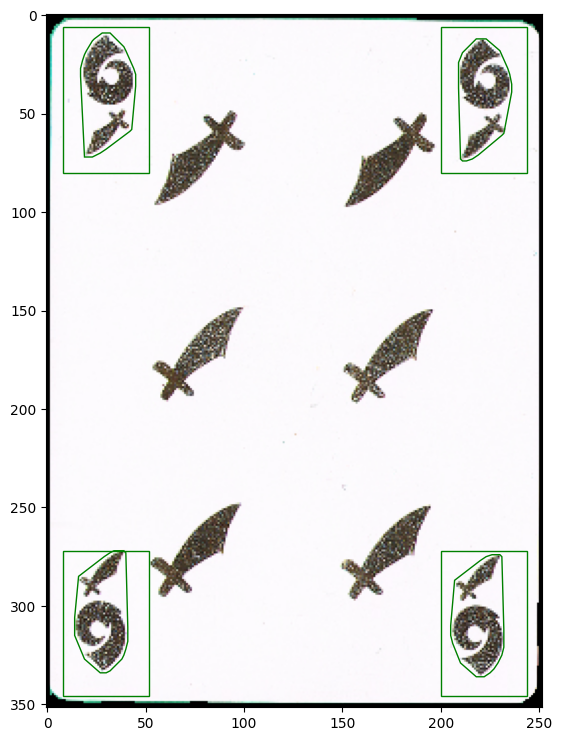

In [16]:
# Test find_hull on a random card image
# debug = "no" or "pause_always" or "pause_on_pb"
# If debug!="no", you may have to press a key to continue execution after pause
debug="no" 
imgs_dir="data/card_scans/extracted"
imgs_fns=glob(imgs_dir+"/*.png")

img_fn=random.choice(imgs_fns)
print(img_fn)
img=cv2.imread(img_fn,cv2.IMREAD_UNCHANGED)

hulls = [findHull(img, corner, debug=debug) for corner in refCorners]
valid_hulls = [h for h in hulls if h is not None]
display_img(img, list(refCorners) + valid_hulls)

if debug!="no": cv2.destroyAllWindows()

### Load all card image, calculate their convex hulls and save the whole in a pickle file (1x)

The next times, we will directly load the pickle file 
The structure saved in the pickle file is a dictionnary named 'cards' of lists of triplets (img,hullHL,hullLR). The keys of the dictionnary are the card names ("Ad","10h",... so 52 entries in the dictionnary). 

In [17]:
import os
import pickle
from glob import glob

import cv2

imgs_dir = "data/cards"
debug = "no"

cards = {}

corner_map = {
    "HL": refCornerHL,
    "HR": refCornerHR,
    "LR": refCornerLR,
    "LL": refCornerLL,
}

# Supported image extensions
img_patterns = ["*.png", "*.jpg", "*.jpeg", "*.webp", "*.bmp", "*.tif", "*.tiff"]

for card_name in card_names:
    card_dir = os.path.join(imgs_dir, card_name)

    if not os.path.isdir(card_dir):
        print(f"!!! Folder {card_dir} does not exist !!!")
        continue

    cards[card_name] = []

    files = []
    for pattern in img_patterns:
        files.extend(glob(os.path.join(card_dir, pattern)))

    if not files:
        print(f"!!! No image files found in {card_dir} !!!")
        continue

    for f in files:
        img = cv2.imread(f, cv2.IMREAD_UNCHANGED)
        if img is None:
            print(f"File {f} could not be read.")
            continue

        hulls = {}
        failed = False

        for name, corner in corner_map.items():
            hulls[name] = findHull(img, corner, debug=debug)
            if hulls[name] is None:
                print(f"File {f} not used: hull {name} not found.")
                failed = True

        if failed:
            continue

        # Convert only if image has alpha channel
        if len(img.shape) == 3 and img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
        elif len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        cards[card_name].append({
            "img": img,
            "hulls": hulls,
            "file": f,  # optional: keep source filename for debugging
        })

    print(f"Nb images for {card_name} : {len(cards[card_name])}")

print("Saved in :", cards_pck_fn)
with open(cards_pck_fn, "wb") as fp:
    pickle.dump(cards, fp)

cv2.destroyAllWindows()

Nb images for black10 : 3
Nb images for black2 : 3
Nb images for black3 : 3
Nb images for black4 : 3
Nb images for black5 : 3
Nb images for black6 : 3
Nb images for black7 : 3
Nb images for black8 : 3
Nb images for black9 : 3
Nb images for blacka : 3
Nb images for blackj : 3
Nb images for blackk : 3
Nb images for blackq : 3
Nb images for blue10 : 3
Nb images for blue2 : 3
Nb images for blue3 : 3
Nb images for blue4 : 3
Nb images for blue5 : 3
Nb images for blue6 : 3
Nb images for blue7 : 3
Nb images for blue8 : 3
Nb images for blue9 : 3
Nb images for bluea : 3
Nb images for bluej : 3
Nb images for bluek : 3
Nb images for blueq : 3
Nb images for dog : 3
Nb images for dragon : 3
Nb images for green10 : 3
Nb images for green2 : 3
Nb images for green3 : 3
Nb images for green4 : 3
Nb images for green5 : 3
Nb images for green6 : 3
Nb images for green7 : 3
Nb images for green8 : 3
Nb images for green9 : 3
Nb images for greena : 3
Nb images for greenj : 3
Nb images for greenk : 3
Nb images for

### Load the cards pickle file in 'cards'
'cards' is an instance of the class Cards
To get a random background image, call the method : cards.get_random() or cards.get_random(card_name) if you want a random card of a given value. Ex: cards.get_random('Ah')

In [18]:
class Cards():
    def __init__(self, cards_pck_fn=cards_pck_fn):
        self._cards = pickle.load(open(cards_pck_fn, 'rb'))
        self._nb_cards_by_value = {k: len(self._cards[k]) for k in self._cards}
        print("Nb of cards loaded per name :", self._nb_cards_by_value)

    def get_random(self, card_name=None, display=False):
        if card_name is None:
            card_name = random.choice(list(self._cards.keys()))

        sample = self._cards[card_name][
            random.randint(0, self._nb_cards_by_value[card_name] - 1)
        ]
        card = sample["img"]
        hulls = sample["hulls"]

        if display:
            display_img(card, list(hulls.values()), "rgb")

        return card, card_name, hulls

    def get_random_card(self, card_name=None, display=False):
        card, card_name, hulls = self.get_random(card_name=card_name, display=display)
        return {
            "img": card,
            "class": card_name,
            "hulls": hulls,
        }


cards = Cards()


Nb of cards loaded per name : {'black10': 3, 'black2': 3, 'black3': 3, 'black4': 3, 'black5': 3, 'black6': 3, 'black7': 3, 'black8': 3, 'black9': 3, 'blacka': 3, 'blackj': 3, 'blackk': 3, 'blackq': 3, 'blue10': 3, 'blue2': 3, 'blue3': 3, 'blue4': 3, 'blue5': 3, 'blue6': 3, 'blue7': 3, 'blue8': 3, 'blue9': 3, 'bluea': 3, 'bluej': 3, 'bluek': 3, 'blueq': 3, 'dog': 3, 'dragon': 3, 'green10': 3, 'green2': 3, 'green3': 3, 'green4': 3, 'green5': 3, 'green6': 3, 'green7': 3, 'green8': 3, 'green9': 3, 'greena': 3, 'greenj': 3, 'greenk': 3, 'greenq': 3, 'mahjong': 3, 'phoenix': 3, 'red10': 3, 'red2': 3, 'red3': 3, 'red4': 3, 'red5': 3, 'red6': 3, 'red7': 3, 'red8': 3, 'red9': 3, 'reda': 3, 'redj': 3, 'redk': 3, 'redq': 3}


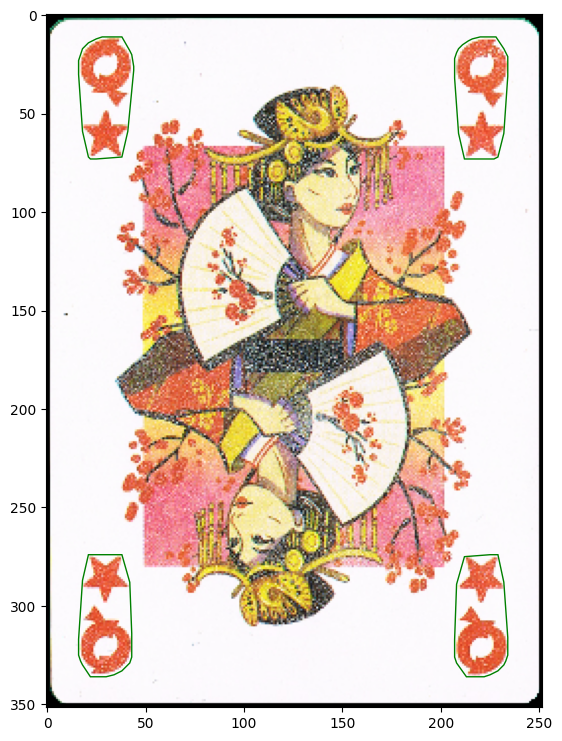

In [19]:
# Test: display a random card
_=cards.get_random(display=True)
# Display a random Ace of spades
#_=cards.get_random("As",display=True)

# Generating a scene
We can now generate a scene (= image of the dataset). We are considering here only 2 kinds of scene (but nothing prevents you to add more scenarios):
1. a scene with 2 cards: each card is randomly transformed (scaled, rotated, translated) independantly from the other;
2. a scene with 3 cards : the 3 cards are grouped together (a bit randomly) to form a fan, then the group is randomly transformed.

|   |   |
|---|---|
|<img src="img/gen_2_cards.jpg" alt="Generated image with 2 cards" title="Generated image with 2 cards" />|<img src="img/gen_3_cards.jpg" alt="Generated image with 3 cards" title="Generated image with 3 cards" />|

### To save bounding boxes annotations in Pascal VOC format 
http://host.robots.ox.ac.uk/pascal/VOC/voc2008/htmldoc/

In [20]:
xml_body_1="""<annotation>
        <folder>FOLDER</folder>
        <filename>{FILENAME}</filename>
        <path>{PATH}</path>
        <source>
                <database>Unknown</database>
        </source>
        <size>
                <width>{WIDTH}</width>
                <height>{HEIGHT}</height>
                <depth>3</depth>
        </size>
"""
xml_object=""" <object>
                <name>{CLASS}</name>
                <pose>Unspecified</pose>
                <truncated>0</truncated>
                <difficult>0</difficult>
                <bndbox>
                        <xmin>{XMIN}</xmin>
                        <ymin>{YMIN}</ymin>
                        <xmax>{XMAX}</xmax>
                        <ymax>{YMAX}</ymax>
                </bndbox>
        </object>
"""
xml_body_2="""</annotation>        
"""

def create_voc_xml(xml_file, img_file,listbba,display=False):
    with open(xml_file,"w") as f:
        f.write(xml_body_1.format(**{'FILENAME':os.path.basename(img_file), 'PATH':img_file,'WIDTH':imgW,'HEIGHT':imgH}))
        for bba in listbba:            
            f.write(xml_object.format(**{'CLASS':bba.classname,'XMIN':bba.x1,'YMIN':bba.y1,'XMAX':bba.x2,'YMAX':bba.y2}))
        f.write(xml_body_2)
        if display: print("New xml",xml_file)
        


In [21]:
# =========================
# FULL SCENE GENERATOR CELL
# =========================

import numpy as np
import random
import cv2
import os
import uuid
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from shapely.geometry import Polygon
from shapely.ops import unary_union

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_, np.object_],
    }

import imgaug as ia
import imgaug.augmenters as iaa


# =========================
# BASIC HELPERS
# =========================

decalX = (imgW - cardW) // 2
decalY = (imgH - cardH) // 2
cardKP = ia.KeypointsOnImage(
    [ia.Keypoint(x=pt[0] + decalX, y=pt[1] + decalY) for pt in refCard],
    shape=(imgH, imgW, 3),
)


def kps_to_polygon(kps):
    pts = [(kp.x, kp.y) for kp in kps]
    poly = Polygon(pts)
    if not poly.is_valid:
        poly = poly.buffer(0)
    return poly


def hull_to_kps(hull, decalX, decalY):
    kps = [ia.Keypoint(x=p[0] + decalX, y=p[1] + decalY) for p in hull.reshape(-1, 2)]
    return ia.KeypointsOnImage(kps, shape=(imgH, imgW, 3))


def kps_to_BB(kps):
    extend = 3
    kpsx = [kp.x for kp in kps.keypoints]
    kpsy = [kp.y for kp in kps.keypoints]

    minx = max(0, int(min(kpsx) - extend))
    maxx = min(imgW, int(max(kpsx) + extend))
    miny = max(0, int(min(kpsy) - extend))
    maxy = min(imgH, int(max(kpsy) + extend))

    if minx >= maxx or miny >= maxy:
        return None

    return ia.BoundingBox(x1=minx, y1=miny, x2=maxx, y2=maxy)


# =========================
# COLOR AUGMENT
# =========================

def degrade_card_color(img_rgba, p=0.8):
    if random.random() > p:
        return img_rgba.copy()

    out = img_rgba.copy()
    rgb = out[:, :, :3].astype(np.float32)
    alpha = out[:, :, 3]

    mode = random.choice(["neutral", "warm", "cold"])

    if mode == "warm":
        r_gain = random.uniform(1.03, 1.18)
        g_gain = random.uniform(0.98, 1.08)
        b_gain = random.uniform(0.85, 0.98)
    elif mode == "cold":
        r_gain = random.uniform(0.85, 0.98)
        g_gain = random.uniform(0.98, 1.08)
        b_gain = random.uniform(1.03, 1.18)
    else:
        r_gain = random.uniform(0.95, 1.05)
        g_gain = random.uniform(0.95, 1.05)
        b_gain = random.uniform(0.95, 1.05)

    rgb[:, :, 0] *= r_gain
    rgb[:, :, 1] *= g_gain
    rgb[:, :, 2] *= b_gain

    rgb *= random.uniform(0.92, 1.08)

    rgb_uint8 = np.clip(rgb, 0, 255).astype(np.uint8)
    hsv = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2HSV).astype(np.float32)

    hsv[:, :, 1] *= random.uniform(0.9, 1.15)
    hsv[:, :, 2] *= random.uniform(0.95, 1.08)
    hsv[:, :, 1:] = np.clip(hsv[:, :, 1:], 0, 255)

    rgb_final = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    out[:, :, :3] = rgb_final
    out[:, :, 3] = alpha
    return out

def add_gaussian_noise_rgb(img, sigma_range=(2, 10)):
    """
    Add mild gaussian sensor noise to RGB image.
    img: uint8 RGB
    """
    out = img.astype(np.float32)
    sigma = random.uniform(*sigma_range)
    noise = np.random.normal(0, sigma, out.shape).astype(np.float32)
    out = np.clip(out + noise, 0, 255).astype(np.uint8)
    return out


def add_poisson_noise_rgb(img, scale_range=(0.8, 1.2), p=0.35):
    """
    Mild shot noise. Applied only sometimes.
    """
    if random.random() > p:
        return img

    scale = random.uniform(*scale_range)
    x = img.astype(np.float32) / 255.0
    vals = np.clip(x * 255.0 * scale, 0, None)
    noisy = np.random.poisson(vals).astype(np.float32) / (255.0 * scale)
    noisy = np.clip(noisy, 0, 1)
    return (noisy * 255).astype(np.uint8)


def add_motion_or_defocus_blur(img, p_motion=0.25, p_gaussian=0.65):
    """
    Add either gaussian blur or light motion blur.
    """
    out = img.copy()

    r = random.random()
    if r < p_gaussian:
        k = random.choice([3, 5])
        sigma = random.uniform(0.2, 1.2)
        out = cv2.GaussianBlur(out, (k, k), sigmaX=sigma, sigmaY=sigma)
    elif r < p_gaussian + p_motion:
        k = random.choice([3, 5, 7])
        kernel = np.zeros((k, k), dtype=np.float32)
        if random.random() < 0.5:
            kernel[k // 2, :] = 1.0
        else:
            kernel[:, k // 2] = 1.0
        kernel /= kernel.sum()
        out = cv2.filter2D(out, -1, kernel)

    return out


def add_jpeg_artifacts(img, quality_range=(45, 95), p=0.5):
    """
    Simulate camera / dataset compression.
    """
    if random.random() > p:
        return img

    quality = random.randint(*quality_range)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    ok, enc = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
    if not ok:
        return img
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)


def add_brightness_gradient(img, strength_range=(0.85, 1.15), p=0.6):
    """
    Apply a soft illumination gradient across the whole image.
    """
    if random.random() > p:
        return img

    h, w = img.shape[:2]
    y = np.linspace(0, 1, h, dtype=np.float32)
    x = np.linspace(0, 1, w, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)

    mode = random.choice(["horizontal", "vertical", "radial"])

    if mode == "horizontal":
        grad = xx
    elif mode == "vertical":
        grad = yy
    else:
        cx = random.uniform(0.2, 0.8)
        cy = random.uniform(0.2, 0.8)
        dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        grad = dist / (dist.max() + 1e-6)

    a = random.uniform(*strength_range)
    b = 2.0 - a
    grad = a + (b - a) * grad
    grad = grad[..., None]

    out = img.astype(np.float32) * grad
    return np.clip(out, 0, 255).astype(np.uint8)


def add_vignette(img, strength_range=(0.08, 0.28), p=0.45):
    """
    Darken edges slightly.
    """
    if random.random() > p:
        return img

    h, w = img.shape[:2]
    y = np.linspace(-1, 1, h, dtype=np.float32)
    x = np.linspace(-1, 1, w, dtype=np.float32)
    xx, yy = np.meshgrid(x, y)
    rr = np.sqrt(xx**2 + yy**2)

    strength = random.uniform(*strength_range)
    mask = 1.0 - strength * np.clip(rr, 0, 1)
    mask = np.clip(mask, 0.75, 1.0)[..., None]

    out = img.astype(np.float32) * mask
    return np.clip(out, 0, 255).astype(np.uint8)


def soften_alpha_edges(img_rgba, p=0.4):
    """
    Slightly soften card edges so pasted cards don't look too perfect.
    Keeps overall alpha structure intact.
    """
    if random.random() > p:
        return img_rgba

    out = img_rgba.copy()
    alpha = out[:, :, 3]

    k = random.choice([3, 5])
    alpha_blur = cv2.GaussianBlur(alpha, (k, k), sigmaX=random.uniform(0.4, 1.0))
    out[:, :, 3] = alpha_blur
    return out


def apply_final_camera_pipeline(img_rgb):
    """
    Apply realistic camera degradations to the composed RGB scene.
    """
    out = img_rgb.copy()

    # Lighting first
    out = add_brightness_gradient(out, strength_range=(0.88, 1.12), p=0.7)
    out = add_vignette(out, strength_range=(0.06, 0.20), p=0.4)

    # Blur before noise often looks more camera-like
    out = add_motion_or_defocus_blur(out, p_motion=0.20, p_gaussian=0.70)

    # Noise
    out = add_gaussian_noise_rgb(out, sigma_range=(1.5, 8.0))
    out = add_poisson_noise_rgb(out, scale_range=(0.8, 1.15), p=0.25)

    # Compression last
    out = add_jpeg_artifacts(out, quality_range=(55, 95), p=0.5)

    return out

def random_card_transform():
    return iaa.Sequential([
        iaa.Affine(scale=(0.68, 1.0)),
        iaa.Affine(rotate=(-180, 180)),
        iaa.Affine(translate_percent={"x": (-0.32, 0.32), "y": (-0.32, 0.32)}),
    ])


scaleBg = iaa.Resize({"height": imgH, "width": imgW})


def is_valid_bb(bb):
    return (
        bb is not None
        and bb.x1 > 0
        and bb.y1 > 0
        and bb.x2 < imgW
        and bb.y2 < imgH
        and bb.x2 > bb.x1
        and bb.y2 > bb.y1
    )


def augment(img, list_kps, seq):
    while True:
        seq_det = seq.to_deterministic()
        img_aug = seq_det.augment_images([img])[0]
        list_kps_aug = [seq_det.augment_keypoints([kp])[0] for kp in list_kps]

        bbs = [kps_to_BB(kps) for kps in list_kps_aug[1:]]

        if all(is_valid_bb(bb) for bb in bbs):
            return img_aug, list_kps_aug, bbs


# =========================
# VISIBILITY LOGIC
# =========================

def visible_poly_after_occlusion(target_poly, occluders):
    if len(occluders) == 0:
        return target_poly
    occ = unary_union(occluders)
    visible = target_poly.difference(occ)
    if not visible.is_valid:
        visible = visible.buffer(0)
    return visible


def bbox_from_visible(corner_poly, occluders, min_ratio=0.22):
    if corner_poly.is_empty:
        return None

    visible = visible_poly_after_occlusion(corner_poly, occluders)
    if visible.is_empty:
        return None

    if visible.area / corner_poly.area < min_ratio:
        return None

    minx, miny, maxx, maxy = visible.bounds
    return ia.BoundingBox(x1=minx, y1=miny, x2=maxx, y2=maxy)


# =========================
# BOUNDING BOX CLASS
# =========================

class BBA:
    def __init__(self, bb, classname):
        self.x1 = int(bb.x1)
        self.y1 = int(bb.y1)
        self.x2 = int(bb.x2)
        self.y2 = int(bb.y2)
        self.classname = classname


# =========================
# MAIN SCENE CLASS
# =========================

class Scene:
    def __init__(self, bg, cards):
        self.bg = scaleBg.augment_image(bg)
        self.cards = cards
        self.listbba = []
        self.build()

    def build(self):
        order = list(range(len(self.cards)))
        random.shuffle(order)

        layers = []
        card_polys = []
        corner_polys = []

        for c in self.cards:
            base = np.zeros((imgH, imgW, 4), dtype=np.uint8)
            base[decalY:decalY + cardH, decalX:decalX + cardW, :] = c["img"]

            hull_names = list(c["hulls"].keys())
            hull_kps = [hull_to_kps(c["hulls"][name], decalX, decalY) for name in hull_names]

            img_aug, lkps, _ = augment(base, [cardKP] + hull_kps, random_card_transform())
            img_aug = degrade_card_color(img_aug)
            img_aug = soften_alpha_edges(img_aug, p=0.35)

            layers.append(img_aug)
            card_polys.append(kps_to_polygon(lkps[0].keypoints))
            corner_polys.append({
                name: kps_to_polygon(kps.keypoints)
                for name, kps in zip(hull_names, lkps[1:])
            })

        final = self.bg.copy()
        ordered_polys = []

        for idx in order:
            layer = layers[idx]
            mask = layer[:, :, 3] > 0
            final = np.where(mask[:, :, None], layer[:, :, :3], final)
            ordered_polys.append((idx, card_polys[idx]))

        self.final = apply_final_camera_pipeline(final)

        pos = {idx: i for i, idx in enumerate(order)}

        for idx, card in enumerate(self.cards):
            occluders = [poly for _, poly in ordered_polys[pos[idx] + 1:]]

            for _, poly in corner_polys[idx].items():
                bb = bbox_from_visible(poly, occluders)
                if bb is not None:
                    self.listbba.append(BBA(bb, card["class"]))

    def display(self):
        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(self.final)
        for bb in self.listbba:
            rect = patches.Rectangle(
                (bb.x1, bb.y1),
                bb.x2 - bb.x1,
                bb.y2 - bb.y1,
                linewidth=1,
                edgecolor='b',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(bb.x1, bb.y1, bb.classname, color='yellow', fontsize=8)

    def res(self):
        return self.final

    def write_files(self, images_dir):
        ensure_dir(images_dir)

        parent_dir = os.path.dirname(images_dir)
        if os.path.basename(images_dir) == "images":
            labels_dir = os.path.join(parent_dir, "labels")
        else:
            labels_dir = os.path.join(parent_dir, "labels")
        ensure_dir(labels_dir)

        stem = uuid.uuid4().hex
        img_file = os.path.join(images_dir, f"{stem}.jpg")
        xml_file = os.path.join(labels_dir, f"{stem}.xml")

        cv2.imwrite(img_file, cv2.cvtColor(self.final, cv2.COLOR_RGB2BGR))
        create_voc_xml(xml_file, img_file, self.listbba)
        return img_file, xml_file


Generated labels: 13


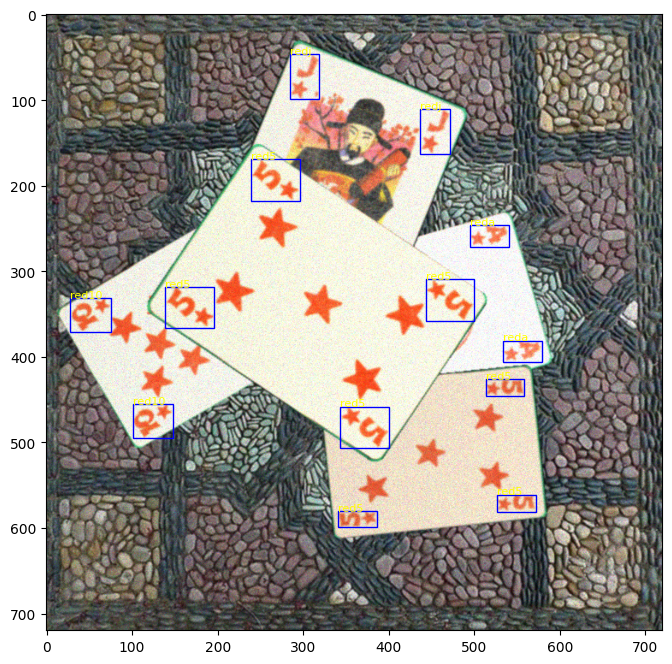

In [22]:
# Test generation of a scene with 2 cards
bg = backgrounds.get_random()
scene_cards = [cards.get_random_card() for _ in range(5)]

newimg = Scene(bg, scene_cards)
newimg.display()
print("Generated labels:", len(newimg.listbba))


## Generate the datasets
Typically, you want to generate a training dataset, a validation dataset and a test data set of different size and different destination directory.
Modify the variable 'nb_cards_to_generate' and 'save_dir' accordingly. We want a directory structure that looks like this:
```
|-- dataset
|   |-- train
|       |-- images
|       |-- labels
|   |-- valid
|       |-- images
|       |-- labels
|   |-- test
|       |-- images
|       |-- labels
|   |-- dataset.yaml
```

- train 56000
- test 11200
- val 11200

### Generation of the cards scenes

In [23]:
import os
import random
from tqdm import tqdm


def sample_card_count(card_count_probs):
    counts = list(card_count_probs.keys())
    probs = list(card_count_probs.values())
    return random.choices(counts, weights=probs, k=1)[0]

def draw_random_cards(nb_cards):
    return [cards.get_random_card() for _ in range(nb_cards)]

def generate_scenes_for_split(split_name, cfg, save_dir):
    ensure_dir(save_dir)

    num_scenes = cfg["num_scenes"]
    card_count_probs = cfg["card_count_probs"]

    if num_scenes < 1:
        raise ValueError("num_scenes must be >= 1")

    # optional: check probs sum ~ 1
    if not abs(sum(card_count_probs.values()) - 1.0) < 1e-6:
        raise ValueError("card_count_probs must sum to 1")

    cards_generated = 0

    pbar = tqdm(total=num_scenes, desc=f"Generating {split_name} scenes")

    for _ in range(num_scenes):
        nb_cards = sample_card_count(card_count_probs)

        bg = backgrounds.get_random()
        newimg = Scene(bg, draw_random_cards(nb_cards))
        newimg.write_files(save_dir)

        cards_generated += nb_cards
        pbar.update(1)

    pbar.close()
    print(
        f"{split_name}: generated {num_scenes} scenes with "
        f"{cards_generated} cards total in {save_dir}"
    )


SPLITS = {
    "train": {
        "num_scenes": 56000,
        "card_count_probs": {
            1: 0.2,
            2: 0.125,
            3: 0.125,
            4: 0.35/3,
            5: 0.35/3,
            6: 0.35/3,
            7: 0.1,
            8: 0.1
        },
    },
    "val": {
        "num_scenes": 11200,
        "card_count_probs": {
            1: 0.2,
            2: 0.125,
            3: 0.125,
            4: 0.35/3,
            5: 0.35/3,
            6: 0.35/3,
            7: 0.1,
            8: 0.1
        },
    },
    "test": {
        "num_scenes": 11200,
        "card_count_probs": {
            1: 0.2,
            2: 0.125,
            3: 0.125,
            4: 0.35/3,
            5: 0.35/3,
            6: 0.35/3,
            7: 0.1,
            8: 0.1
        },
    },
}


for split_name, cfg in SPLITS.items():
    base_dir = os.path.join("data", "scenes", split_name, "images")
    generate_scenes_for_split(split_name, cfg, base_dir)

Generating train scenes: 100%|██████████| 56000/56000 [4:20:56<00:00,  3.58it/s]   


train: generated 56000 scenes with 228954 cards total in data\scenes\train\images


Generating val scenes: 100%|██████████| 11200/11200 [52:24<00:00,  3.56it/s] 


val: generated 11200 scenes with 46310 cards total in data\scenes\val\images


Generating test scenes: 100%|██████████| 11200/11200 [51:54<00:00,  3.60it/s] 

test: generated 11200 scenes with 45551 cards total in data\scenes\test\images


### Convert Annotations VOC to YOLO Format

In [26]:
!python convert_voc_yolo.py data/scenes/train/labels data/scenes/train/labels data/cards.names
!python convert_voc_yolo.py data/scenes/val/labels data/scenes/val/labels data/cards.names
!python convert_voc_yolo.py data/scenes/test/labels data/scenes/test/labels data/cards.names


Classes: ['black10', 'black2', 'black3', 'black4', 'black5', 'black6', 'black7', 'black8', 'black9', 'blacka', 'blackj', 'blackk', 'blackq', 'blue10', 'blue2', 'blue3', 'blue4', 'blue5', 'blue6', 'blue7', 'blue8', 'blue9', 'bluea', 'bluej', 'bluek', 'blueq', 'dog', 'dragon', 'green10', 'green2', 'green3', 'green4', 'green5', 'green6', 'green7', 'green8', 'green9', 'greena', 'greenj', 'greenk', 'greenq', 'mahjong', 'phoenix', 'red10', 'red2', 'red3', 'red4', 'red5', 'red6', 'red7', 'red8', 'red9', 'reda', 'redj', 'redk', 'redq'] Total: 56
Processed 100 files
Processed 200 files
Processed 300 files
Processed 400 files
Processed 500 files
Processed 600 files
Processed 700 files
Processed 800 files
Processed 900 files
Processed 1000 files
Processed 1100 files
Processed 1200 files
Processed 1300 files
Processed 1400 files
Processed 1500 files
Processed 1600 files
Processed 1700 files
Processed 1800 files
Processed 1900 files
Processed 2000 files
Processed 2100 files
Processed 2200 files
Pro

### Create YAML file for the generated dataset

```yaml
path: C:/Users/maxan/Hobby/Inforelektrikbau/Tichu-Bot/software/tichu-card-detection/data/scenes

train: train/images
val: val/images
test: test/images

names:
  0: black10
  1: black2
  2: black3
  3: black4
  4: black5
  5: black6
  6: black7
  7: black8
  8: black9
  9: blacka
  10: blackj
  11: blackk
  12: blackq
  13: blue10
  14: blue2
  15: blue3
  16: blue4
  17: blue5
  18: blue6
  19: blue7
  20: blue8
  21: blue9
  22: bluea
  23: bluej
  24: bluek
  25: blueq
  26: dog
  27: dragon
  28: green10
  29: green2
  30: green3
  31: green4
  32: green5
  33: green6
  34: green7
  35: green8
  36: green9
  37: greena
  38: greenj
  39: greenk
  40: greenq
  41: mahjong
  42: phoenix
  43: red10
  44: red2
  45: red3
  46: red4
  47: red5
  48: red6
  49: red7
  50: red8
  51: red9
  52: reda
  53: redj
  54: redk
  55: redq
```